In [1]:
#This second test uses voltage values for the plots instead of collected energies. This uses the ESR to generate a proper value for the collected voltage. 

#All of the imports
import sionna.rt
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions

#Animation
import matplotlib.animation as animation

import matplotlib as mpl

using_preview = True

In [2]:
min_distance_between_points = 15
def distance_between(a, b):
    return math.sqrt(math.pow(b[1] - a[1], 2) + math.pow(b[2]-a[2], 2))

#returns true if the position isn't close to o
def check_position_valid(pos, positions_array):
    for other_pos in positions_array:
        if(distance_between(pos, other_pos) < min_distance_between_points):
            return False
    
    return True

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


| Type   |   Recieved Power (dbm) |   DC energy (dbm) | time (s)   |
|--------+------------------------+-------------------+------------|
| Mean   |               -33.118  |         -140      |            |
| Q1     |               -34.86   |         -140      |            |
| Median |               -30.0883 |         -140      |            |
| Q3     |               -26.9071 |          -35.9029 |            |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 60.141%         | 39.859%    | 0.000%       |


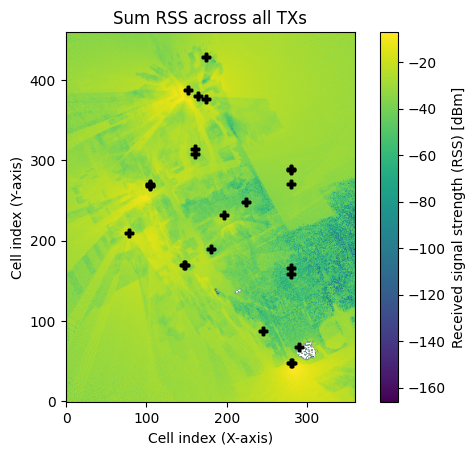

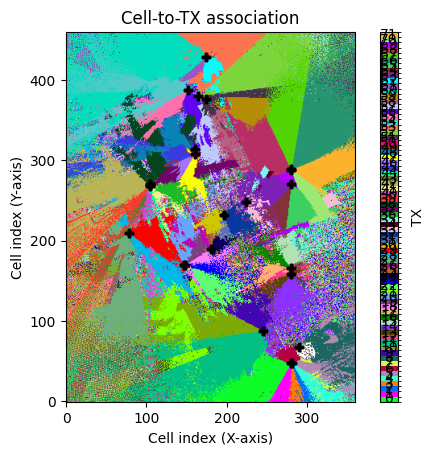

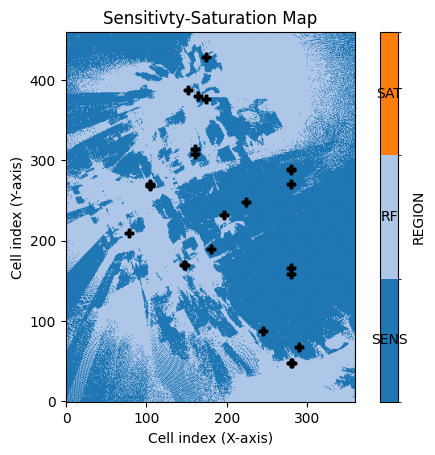

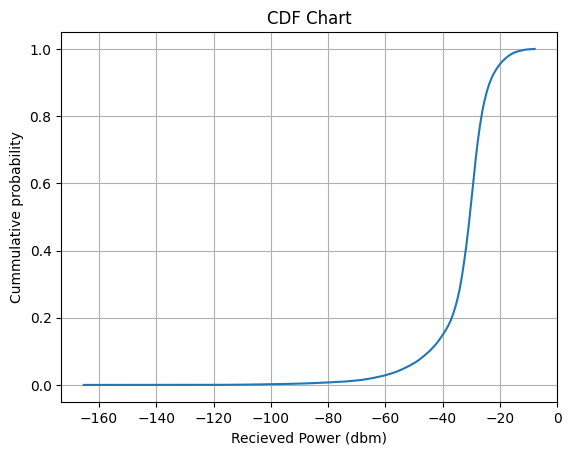

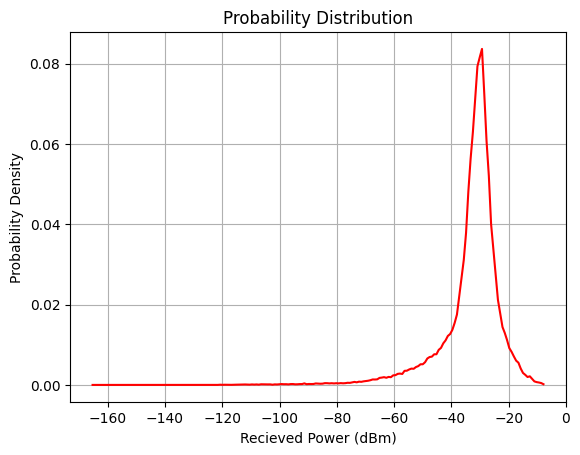

In [3]:
current_scene = load_scene("Blender_from_sketchup/UBC_detailed.xml")

current_scene.frequency = 1.0001e9
num_cols = 1
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="VH")

current_scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="VH")


transmitters = []


positions_array = []

positions_array = [
    [500, -900, 27],
    [505, -900, 27],
    [550, -800, 27],
    [325, -700, 27],
    [500, -350, 30],
    [500, -310, 30],


    [-160, -290, 60],
    [-165, -290, 60],
    [0, -190, 30],
    [-510, -90, 42],
    [80, 20, 25],
    [220, 100, 37],


    [-380, 200, 40],
    [-380, 205, 40],
    [-380, 210, 40],
    [-100, 400, 20],
    [-100, 430, 20],
    [-80, 760, 75],


    [-140, 800, 25],
    [-30, 740, 75],
    [-30, 1000, 30],
    [500, 210, 27],
    [500, 300, 27], 
    [500, 305, 27]
]

powers_array = [46, 49, 0, 0, 0, 0, 
                
                46, 46, 0, 49.8, 46.8, 0, 
                
                43, 40, 49.8, 0, 0, 49.8, 
                
                49.8, 40, 0, 0, 0, 0]

for i,_position in enumerate(positions_array):
    transmitters.append(Transmitter(name=f"tx{i}_1", position=_position, display_radius=10, power_dbm=powers_array[i]))
    first_angle = random.random()*360.0
    transmitters[-1].orientation = (first_angle, 0, 0)
    current_scene.add(transmitters[-1])

    transmitters.append(Transmitter(name=f"tx{i}_2", position=_position, display_radius=10, power_dbm=powers_array[i]))
    transmitters[-1].orientation = (first_angle+120, 0, 0)
    current_scene.add(transmitters[-1])

    transmitters.append(Transmitter(name=f"tx{i}_3", position=_position, display_radius=10, power_dbm=powers_array[i]))
    transmitters[-1].orientation = (first_angle+240, 0, 0)
    current_scene.add(transmitters[-1])
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")


metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


| Type   |   Recieved Power (dbm) |   DC energy (dbm) | time (s)   |
|--------+------------------------+-------------------+------------|
| Mean   |               -33.118  |         -140      |            |
| Q1     |               -34.86   |         -140      |            |
| Median |               -30.0883 |         -140      |            |
| Q3     |               -26.9071 |          -35.9029 |            |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 60.141%         | 39.859%    | 0.000%       |


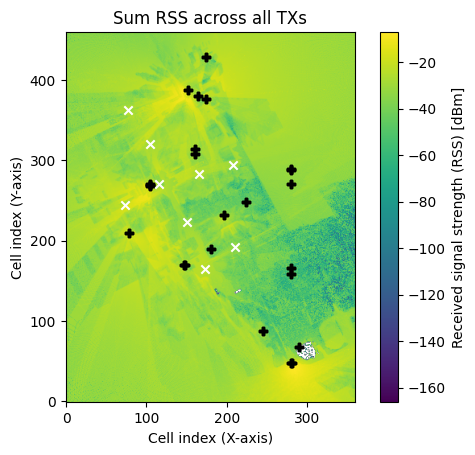

-21.8435 dbm
-26.9495 dbm
-28.231 dbm
-33.3884 dbm
-31.8367 dbm
-24.398 dbm
-31.3812 dbm
-26.2211 dbm
-30.3827 dbm


In [4]:
#Plotting reciever positions
sample_cell_positions = [
    [73, 244],
    [77, 363],
    [105,320],
    [116,270],
    [150,223],
    [173,165],
    [210,192],
    [165,283],
    [208,294]
]

for i in range(len(sample_cell_positions)):
    position = mi.Point3f([sample_cell_positions[i][0], sample_cell_positions[i][1], 1])
    position *= 5
    position -= mi.Point3f([900, 1150, 0]) #Center at middle of array
    position += mi.Point3f([0, 10, 0]) #Add offset of radio_map

    current_scene.add(Receiver(name=f"rx_{i}", position = position))


rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

radio_functions.show_sum(rm, metric="rss", show_rx=True)
current_scene.preview(radio_map=rm);


for position in sample_cell_positions:
    print(f"{radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[position[1]][position[0]])} dbm")


z = 0


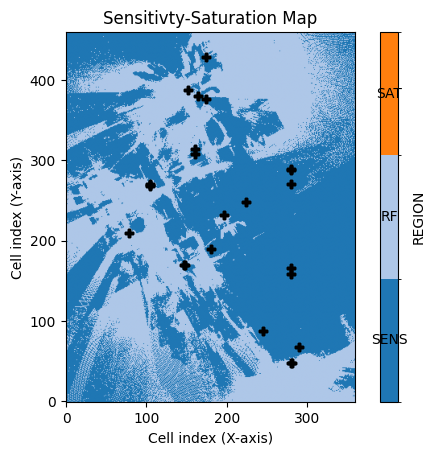

-23.0619 dbm
-25.5422 dbm
-26.3808 dbm
-32.5037 dbm
-33.0052 dbm
-24.4418 dbm
-33.4651 dbm
-24.6602 dbm
-51.571 dbm
z = 1


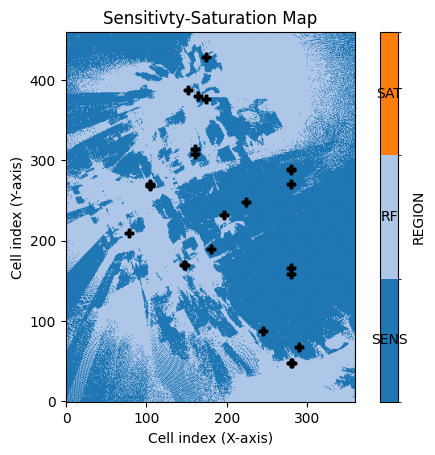

-21.8435 dbm
-26.9495 dbm
-28.231 dbm
-33.3884 dbm
-31.8367 dbm
-24.398 dbm
-31.3812 dbm
-26.2211 dbm
-30.3827 dbm
z = 2


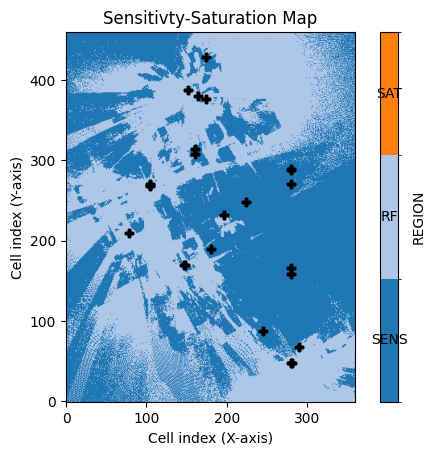

-20.1811 dbm
-26.7751 dbm
-29.1119 dbm
-26.5469 dbm
-30.5922 dbm
-24.3236 dbm
-29.8193 dbm
-25.3667 dbm
-31.0004 dbm
z = 3


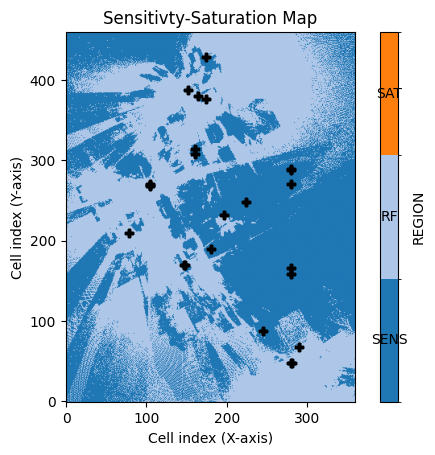

-19.1954 dbm
-25.1076 dbm
-27.3139 dbm
-26.8501 dbm
-31.4279 dbm
-24.4532 dbm
-27.4565 dbm
-25.9834 dbm
-29.832 dbm
z = 4


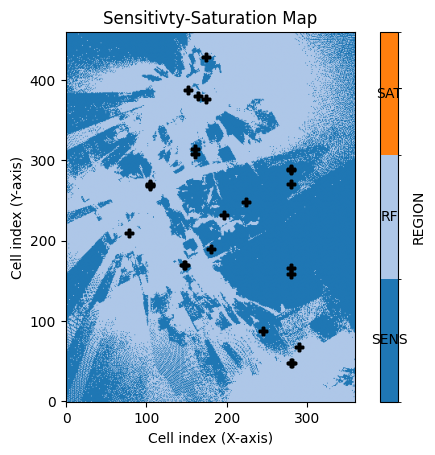

-18.1623 dbm
-25.7457 dbm
-28.2777 dbm
-27.0182 dbm
-32.1944 dbm
-17.5962 dbm
-29.481 dbm
-25.3846 dbm
-31.4931 dbm


In [5]:
for i in range(5):
    rm = rm_solver(current_scene,
                max_depth=30,           # Maximum number of ray scene interactions
                samples_per_tx=10**7 , # If you increase: less noise, but more memory required
                cell_size=(5, 5),      # Resolution of the radio map
                center=[0, 10, i],      # Center of the radio map
                size=[1800, 2300],       # Total size of the radio map
                orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    print(f"z = {i}")    
    radio_functions.show_DC_regions(rm, metric="rss")


    for position in sample_cell_positions:
        print(f"{radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[position[1]][position[0]])} dbm")
